# Поиск оптимального количества кластеров методом локтя

Найдем оптимальное значение `N_CLUSTERS` для кластеризации временных рядов, используя метод локтя

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('.')

from config import *
from loader import load_and_sample_series
from features import create_feature_matrix

## Загрузка данных

In [4]:
all_series = load_and_sample_series(DATA_PATH, N_SERIES)

Загрузка рядов из 6 файлов в Train...
Загружено 200 рядов.


In [5]:
feature_df = create_feature_matrix(all_series)
print(f"Размерность матрицы признаков: {feature_df.shape}")

Размерность матрицы признаков: (200, 14)


Для достижения лучшего результата стандартизируем признаки перед кластеризацией. Это поможет алгоритму KMeans работать более эффективно, так как все признаки будут находиться в одном масштабе.

In [6]:
scaler = StandardScaler()
feature_scaled = scaler.fit_transform(feature_df)

## Метод локтя

k=1, SSE=2600.00
k=2, SSE=1722.63
k=3, SSE=1305.75
k=4, SSE=976.68
k=5, SSE=843.04
k=6, SSE=743.34
k=7, SSE=638.23
k=8, SSE=573.81
k=9, SSE=516.21
k=10, SSE=474.54


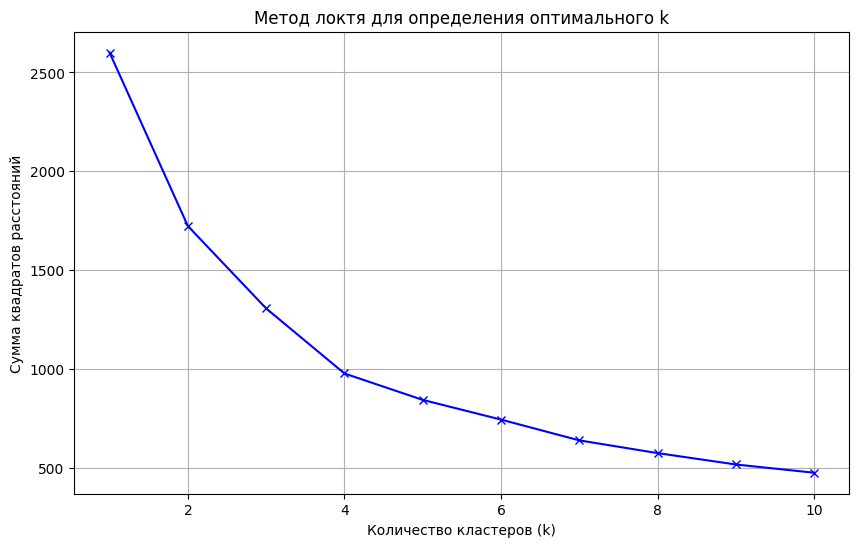

In [7]:
k_range = range(1, 11)
errors = []  

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=CLUSTER_RANDOM_STATE, n_init=10)
    kmeans.fit(feature_scaled)
    errors.append(kmeans.inertia_)
    print(f"k={k}, SSE={kmeans.inertia_:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, errors, 'bx-')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов расстояний')
plt.title('Метод локтя для определения оптимального k')
plt.grid(True)
plt.show()

## Выводы

Оптимальное количество кластеров находится в точке "локтя" - где снижение SSE начинает замедляться. По графику можно определить, что оптимальное значение `N_CLUSTERS` находится в районе k=4, так как после этого значения снижение SSE становится менее резким.